# Using Web Map API through the map widget - graphics drawn on map widget
Notebook demonstrating various capabilities of the new web map API

In [1]:
from arcgis.gis import *
from arcgis.mapping_layers import WebMap
from arcgis.raster import apply
from arcgis.features import FeatureLayer
from arcgis.geocoding import geocode
from arcgis.features import Feature, FeatureSet, FeatureCollection
from arcgis.mapping_layers import MapImageLayer
import json
from arcgis.geometry import Point, Polyline, Polygon, Envelope

In [2]:
gis = GIS("https://www.arcgis.com","arcgis_python")
anon_gis= GIS(set_active=False)

Enter password: ········


Some regular layers

<Item title:"Census Blocks 2010 (with 2017 and 2022 Data)" type:Feature Layer Collection owner:JohnsCreekGA>
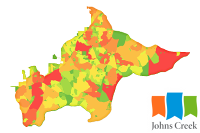

In [3]:
flc_item = gis.content.get('8d29d4a521f34ebba40dd918ac8322c3')
flc_item

<Item title:"GAWeatherStations" type:Map Image Layer owner:rbagby_gema>
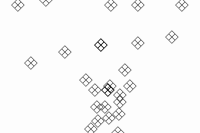

In [4]:
mil_item = gis.content.get('c6719c88770f402690c0ca25afe8c405')
mil_item

In [5]:
mil = MapImageLayer("https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer")
mil

<MapImageLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer">

<Item title:"Terrain" type:Imagery Layer owner:esri>
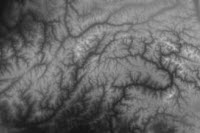

In [14]:
il_item = gis.content.get('58a541efc59545e6b7137f961d7de883')
il_item

## Draw different graphics
General data source - [http://data-georgiagio.opendata.arcgis.com/datasets](http://data-georgiagio.opendata.arcgis.com/datasets)
### Regular shapes

In [7]:
map1 = gis.map("Duluth, GA")
map1

In [8]:
map1.draw("rectangle")

In [9]:
map1.draw('circle')

In [9]:
map1.draw('rightarrow')

In [10]:
map1.draw('freehandpolyline')

In [11]:
map1.draw('point')

In [12]:
dg = json.loads(map1._js_interactive_drawn_graphic)
len(dg)

5

In [ ]:
dg[0]['geometry']

In [10]:
map1._webmap_drawn_layer_list

[]

In [10]:
map1.add_layer(flc_item)

In [20]:
il = il_item.layers[0]
from arcgis.raster import hillshade, stretch
hill_il = hillshade(il)
map1.add_layer(hill_il)

### Save the web map

In [21]:
wm_item1 = map1.save("GA WM with popups2", "Created using Notebooks", ['automation', 'science'])
wm_item1

<Item title:"GA WM with popups2" type:Web Map owner:arcgis_python>

## Draw graphics - sent as dictionaries and FeatureSet objects

In [16]:
map2 = gis.map("Columbia, SC", zoomlevel=10)
map2

In [11]:
map2.draw([34, -81])

In [22]:
columbia = geocode("Columbia, SC")[0]
c_groceries = geocode("groceries", search_extent=columbia['extent'], as_featureset=True)
c_groceries

<FeatureSet> 20 features

In [23]:
symbol =  {"color":[0,0,128,128],"size":18,"angle":0,"xoffset":0,"yoffset":0,"type":"esriSMS","style":"esriSMSDiamond","outline":{"color":[0,0,128,255],"width":1,"type":"esriSLS","style":"esriSLSSolid"}}
map2.draw(c_groceries, symbol=symbol)

In [24]:
map2.draw('ellipse')

In [26]:
map2.basemap = 'gray-vector'

In [27]:
wm_item2 = map2.save("SC WM with drawn graphics and Geocoded results", 
                     "Created using Notebooks and Python API", ['reproducible research'])
wm_item2

<Item title:"SC WM with drawn graphics and Geocoded results" type:Web Map owner:arcgis_python>

## Ensure remove layers works fine
Removing layers should not mess up added, drawn layers

In [13]:
map3 = gis.map("Duluth, GA", zoomlevel=10)
map3

In [12]:
map3.add_layer(flc_item)
map3.add_layer(mil_item)
map3.add_layer(mil.layers)

In [84]:
map3.draw('rectangle')

In [83]:
map3.draw('line')

In [16]:
map3.layers

[<Item title:"GAWeatherStations" type:Map Image Layer owner:rbagby_gema>,
 <FeatureLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/1">,
 <FeatureLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/2">]

In [15]:
map3.remove_layers([map3.layers[0], map3.layers[2], map3.layers[-1]])

True

In [17]:
map3.remove_layers()

In [10]:
map3._webmap.layers

[]

In [11]:
map3._js_layer_list

'[]'